<a href="https://colab.research.google.com/github/rightchel/mirea-hi/blob/main/%D0%90%D0%BD%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_hh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
vacancies = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Python 2024-2025/data/adjusted_vacancies_2024.csv')
vacancies.head()

,premium,name,has_test,response_letter_required,department_id,department_name,area_id,area_name,salary_from,salary_to,...,employer_name,schedule_id,experience_id,employment_id,is_address,is_insider_interview,salary_from_rub,salary_to_rub,"(False, 'salary_from_rub')","(False, 'salary_to_rub')"
0,False,Специалист по работе с данными (Excel) / Анали...,False,False,NaN,NaN,1,Москва,170000.0,170000.0,...,ЦУГАМ,fullDay,between1And3,full,True,False,170000.0,170000.0,170000.0,170000.0
1,False,Data Analyst,False,False,NaN,NaN,2,Санкт-Петербург,60000.0,80000.0,...,LoyaltyPlant,flexible,noExperience,full,False,False,60000.0,80000.0,60000.0,80000.0
2,False,"Аналитик по обработке данных (удалённо, проект...",False,False,NaN,NaN,1,Москва,80000.0,80000.0,...,ЛУКОЙЛ,remote,noExperience,full,False,False,80000.0,80000.0,80000.0,80000.0
3,False,Специалист по разметке данных для машинного об...,False,False,NaN,NaN,2,Санкт-Петербург,25000.0,NaN,...,Корда Групп,remote,noExperience,full,True,False,25000.0,NaN,25000.0,NaN
4,False,Младший аналитик данных,False,False,NaN,NaN,1,Москва,NaN,NaN,...,Ростелеком - Центры обработки данных,fullDay,noExperience,full,True,False,NaN,NaN,NaN,NaN


In [ ]:
vacancies.shape

(2000, 23)

In [ ]:
vacancies.columns

Index(['premium', 'name', 'has_test', 'response_letter_required',
       'department_id', 'department_name', 'area_id', 'area_name',
       'salary_from', 'salary_to', 'salary_currency', 'salary_gross',
       'type_id', 'employer_name', 'schedule_id', 'experience_id',
       'employment_id', 'is_address', 'is_insider_interview',
       'salary_from_rub', 'salary_to_rub', '(False, 'salary_from_rub')',
       '(False, 'salary_to_rub')'],
      dtype='object')

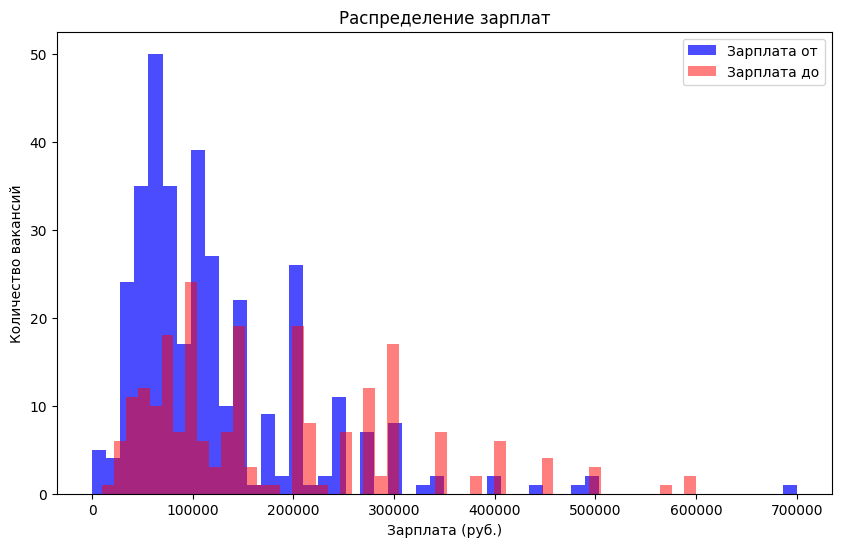

In [ ]:
def analyze_salary_distribution(df):
    plt.figure(figsize=(10, 6))
    plt.hist(df['salary_from_rub'], bins=50, alpha=0.7, color='blue', label='Зарплата от')
    plt.hist(df['salary_to_rub'], bins=50, alpha=0.5, color='red', label='Зарплата до')
    plt.title('Распределение зарплат')
    plt.xlabel('Зарплата (руб.)')
    plt.ylabel('Количество вакансий')
    plt.legend()
    plt.show()

# Применение функции
analyze_salary_distribution(vacancies)


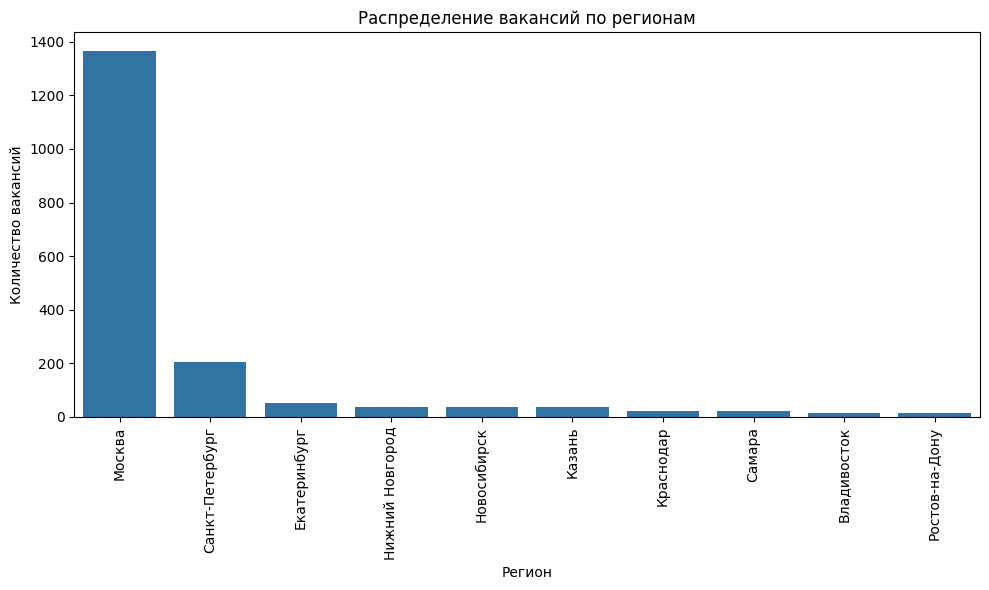

In [ ]:
def analyze_vacancies_by_area(df):
    area_counts = df['area_name'].value_counts().head(10)
    plt.figure(figsize=(10, 6))
    sns.countplot(x='area_name', data=df, order=area_counts.index)
    plt.title('Распределение вакансий по регионам')
    plt.xlabel('Регион')
    plt.ylabel('Количество вакансий')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Применение функции
analyze_vacancies_by_area(vacancies)


In [ ]:
vacancies['experience_id'].unique()

array(['between1And3', 'noExperience', 'between3And6', 'moreThan6'],
      dtype=object)

In [ ]:
vacancies['experience_id'] = vacancies['experience_id'].map({'noExperience': 0, 'between1And3': 1, 'between3And6': 3, 'moreThan6': 6})

In [ ]:
vacancies['experience_id'].unique()

array([1, 0, 3, 6])

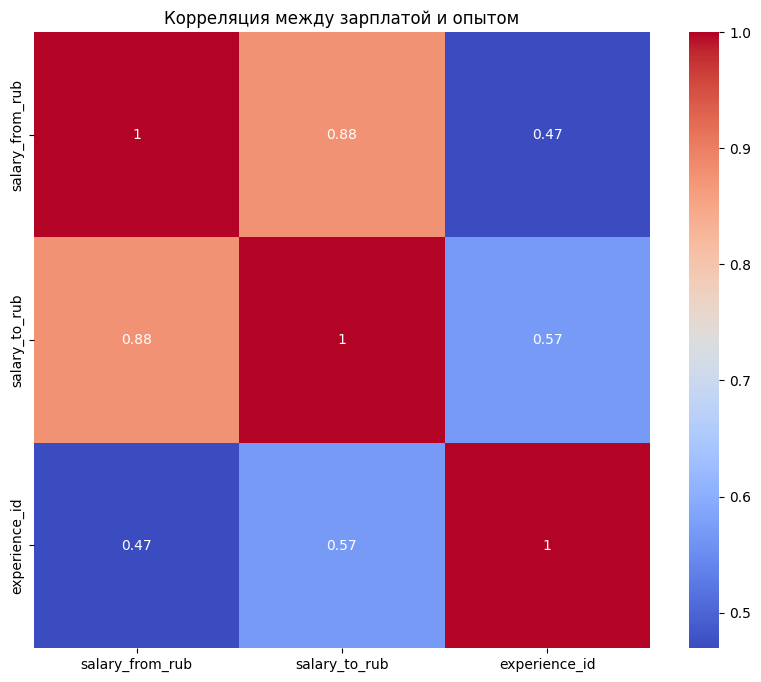

In [ ]:
def analyze_correlation(df):
    corr_matrix = df[['salary_from_rub', 'salary_to_rub', 'experience_id']].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
    plt.title('Корреляция между зарплатой и опытом')
    plt.show()

# Применение функции
analyze_correlation(vacancies)


In [ ]:
def avg_salary(df):
  # Создайте новый столбец 'avg_salary_rub'
  df['avg_salary_rub'] = df.apply(lambda row:
                                  (row['salary_from_rub'] + row['salary_to_rub']) / 2
                                  if pd.notnull(row['salary_from_rub']) and pd.notnull(row['salary_to_rub'])
                                  else row['salary_from_rub'] if pd.isnull(row['salary_to_rub'])
                                  else row['salary_to_rub'], axis=1)

  return df

In [ ]:
vacancies = avg_salary(vacancies)

Средняя зарплата: 140857.32991160313
Медианная зарплата: 100000.0


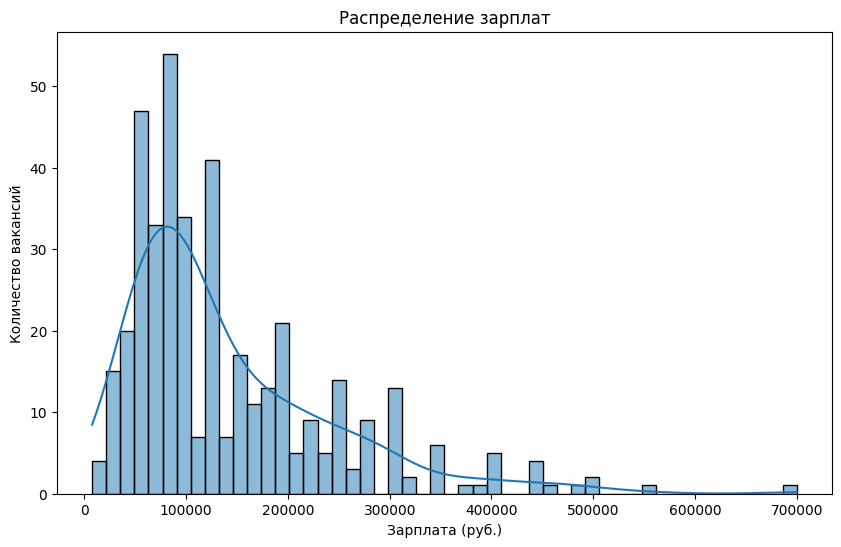

In [ ]:
# Средняя и медианная зарплата
avg_salary = vacancies['avg_salary_rub'].mean()
median_salary = vacancies['avg_salary_rub'].median()

print(f"Средняя зарплата: {avg_salary}")
print(f"Медианная зарплата: {median_salary}")

# Диапазон зарплат
plt.figure(figsize=(10, 6))
sns.histplot(vacancies['avg_salary_rub'], bins=50, kde=True)
plt.title('Распределение зарплат')
plt.xlabel('Зарплата (руб.)')
plt.ylabel('Количество вакансий')
plt.show()


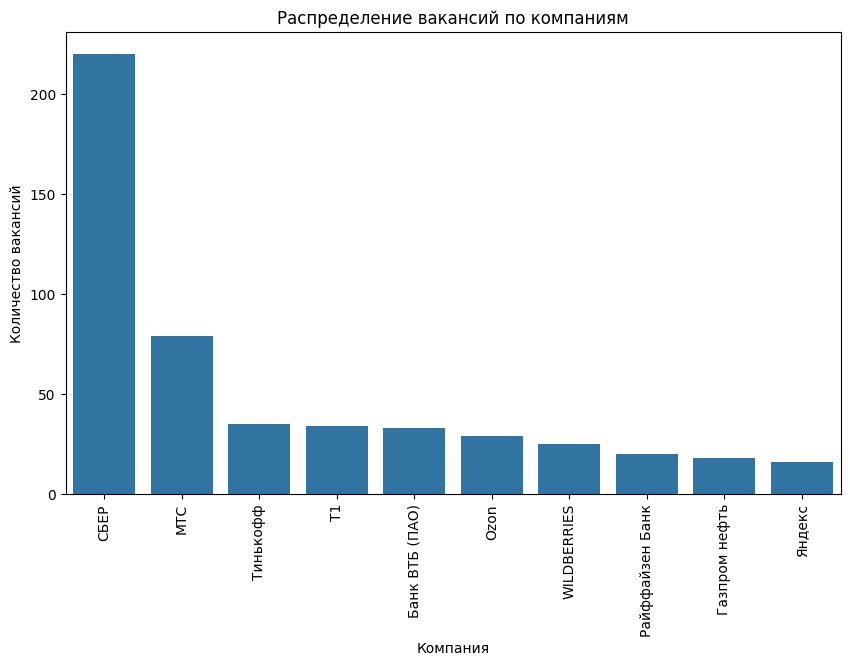

In [ ]:
# Конкурентный анализ
top_companies = vacancies['employer_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.countplot(x='employer_name', data=vacancies, order=top_companies.index)
plt.title('Распределение вакансий по компаниям')
plt.xlabel('Компания')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=90)
plt.show()


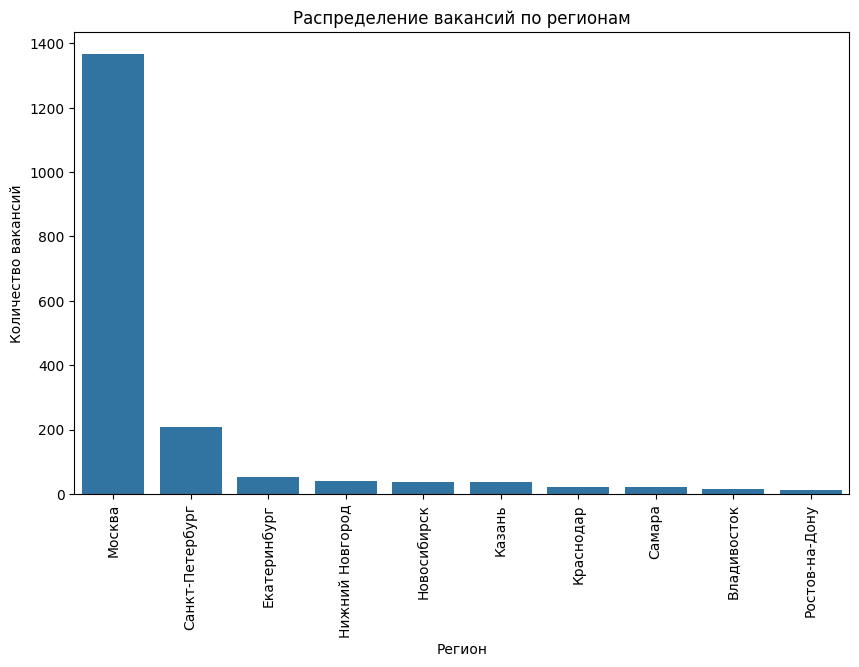

In [ ]:
# Географическое распределение
area_counts = vacancies['area_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.countplot(x='area_name', data=vacancies, order=area_counts.index)
plt.title('Распределение вакансий по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=90)
plt.show()

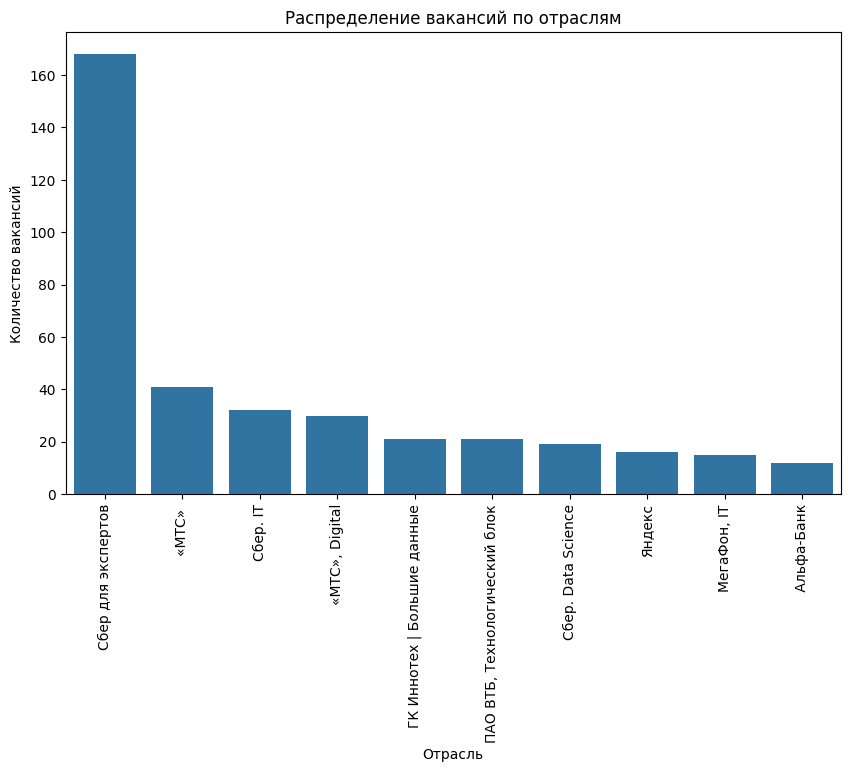

In [ ]:
# Отраслевое распределение
department_counts = vacancies['department_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.countplot(x='department_name', data=vacancies, order=department_counts.index)
plt.title('Распределение вакансий по отраслям')
plt.xlabel('Отрасль')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=90)
plt.show()

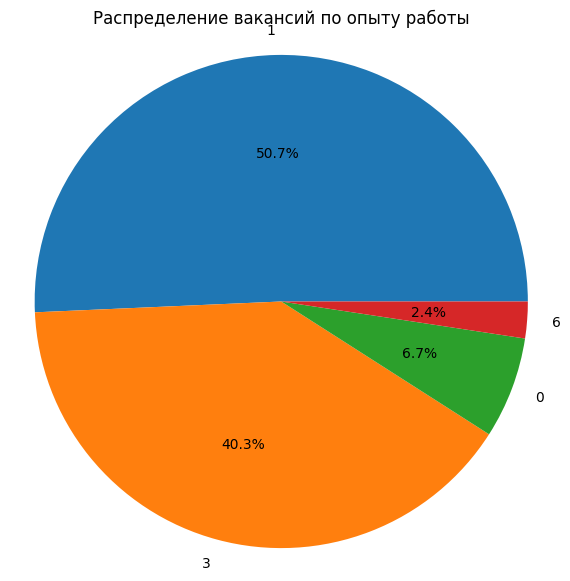

In [ ]:
# Подсчет количества вакансий для каждого уровня опыта
experience_counts = vacancies['experience_id'].value_counts()

# Создание круговой диаграммы
plt.figure(figsize=(7, 7))
plt.pie(experience_counts, labels=experience_counts.index, autopct='%1.1f%%')
plt.title('Распределение вакансий по опыту работы')
plt.axis('equal')  # Чтобы круговая диаграмма была круглой
plt.show()

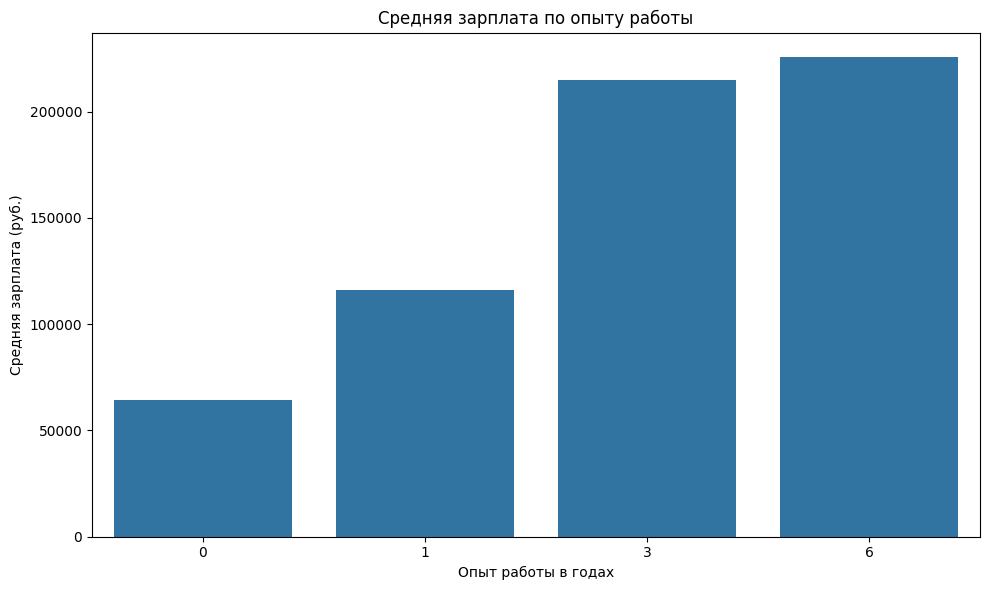

In [ ]:
# Группировка по опыту работы и расчет средней зарплаты
avg_salary_by_experience = vacancies.groupby('experience_id')['avg_salary_rub'].mean().reset_index()

# Создание графика
plt.figure(figsize=(10, 6))
sns.barplot(x='experience_id', y='avg_salary_rub', data=avg_salary_by_experience)
plt.title('Средняя зарплата по опыту работы')
plt.xlabel('Опыт работы в годах')
plt.ylabel('Средняя зарплата (руб.)')
plt.xticks(rotation=0)  # Чтобы подписи не перекрывались
plt.tight_layout()  # Чтобы подписи не выходили за пределы графика
plt.show()


In [ ]:
avg_salary_by_experience

,experience_id,avg_salary_rub
0,0,64521.459677
1,1,116086.973910
2,3,214835.748376
3,6,225990.346154


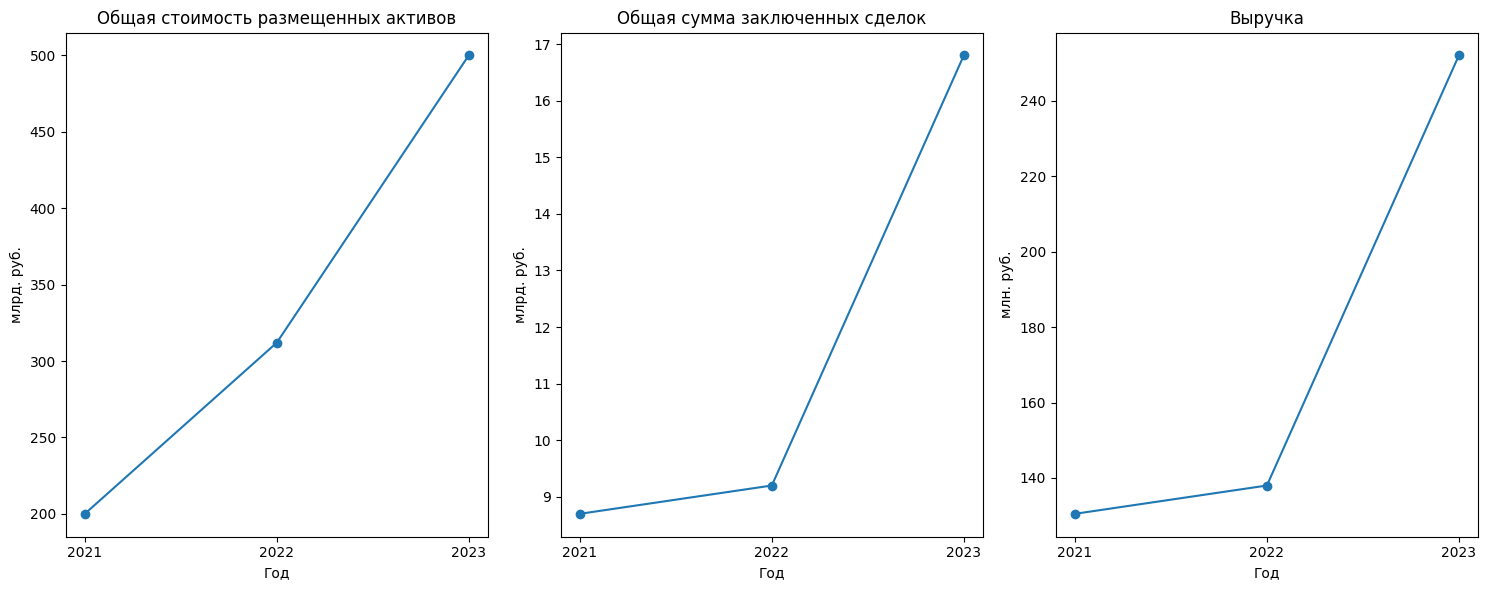

In [ ]:
import matplotlib.pyplot as plt

# Данные
years = [2021, 2022, 2023]
assets_value = [200, 312, 500]  # млрд руб.
deals_sum = [8.7, 9.2, 16.8]  # млрд руб.
revenue = [r * 0.015 for r in deals_sum]  # млрд руб. (1% от общей суммы сделок)

# Пересчет выручки в миллионы
revenue_millions = [r * 1000 for r in revenue]

# Создание графика
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(years, assets_value, marker='o')
plt.title('Общая стоимость размещенных активов')
plt.xlabel('Год')
plt.ylabel('млрд. руб.')
plt.xticks(years)  # Отображать только годы из массива

plt.subplot(1, 3, 2)
plt.plot(years, deals_sum, marker='o')
plt.title('Общая сумма заключенных сделок')
plt.xlabel('Год')
plt.ylabel('млрд. руб.')
plt.xticks(years)  # Отображать только годы из массива

plt.subplot(1, 3, 3)
plt.plot(years, revenue_millions, marker='o')
plt.title('Выручка')
plt.xlabel('Год')
plt.ylabel('млн. руб.')
plt.xticks(years)  # Отображать только годы из массива

plt.tight_layout()
plt.show()
